# Autoencoder + PCA preprocessing for Quantum ML

This notebook loads the `classical_qi_predictions_all_splits` dataset, applies PCA and an autoencoder to reduce dimensionality, and saves the transformed embeddings for downstream Quantum ML experiments.

## Dataset

The notebook expects the dataset at `outputs/classical_qi_predictions_all_splits.csv` relative to this notebook's folder.

In [41]:
# Imports and environment checks
import os
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import torch
from torch import nn

print('pandas', pd.__version__)
print('numpy', np.__version__)
print('sklearn available')
print('torch', torch.__version__)

pandas 3.0.2
numpy 1.26.4
sklearn available
torch 2.2.2


In [42]:
# Paths and loading
data_path = Path('/Users/stefan/Python_Projekte/4BE/QCentroid - ETH Hackathon 2026/aggregated_source_data.csv')
assert data_path.exists(), f'Data not found: {data_path}'
df = pd.read_csv(data_path)
print('Loaded', data_path)

display(df)

print(df['is_malicious_source'].max())

Loaded /Users/stefan/Python_Projekte/4BE/QCentroid - ETH Hackathon 2026/aggregated_source_data.csv


,family,split,scenario,dataset_name,src_ip,flow_count,unique_dst_ip,unique_dst_port,unique_protocols,pps_mean,...,dst_port_concentration,top_dst_ip,top_protocol,tcp_share,udp_share,icmp_share,small_packet_share,high_pps_share,low_outbound_share,is_malicious_source
0,family_a,test,attack,attack_test_01,59.166.0.7,9360,10,2934,2,2822.727850,...,0.211325,149.171.126.0,TCP,0.772650,0.227350,0.0,0.618483,0.064530,0.052350,0
1,family_a,test,attack,attack_test_01,59.166.0.8,9390,10,2878,2,2807.146043,...,0.220980,149.171.126.1,TCP,0.781470,0.218530,0.0,0.618637,0.063685,0.051757,0
2,family_a,test,attack,attack_test_01,59.166.0.0,9797,10,2919,2,2793.548094,...,0.217618,149.171.126.0,TCP,0.770644,0.229356,0.0,0.621823,0.060937,0.054098,0
3,family_a,test,attack,attack_test_01,59.166.0.4,9782,10,3046,2,2857.151556,...,0.208444,149.171.126.4,TCP,0.773359,0.226641,0.0,0.615007,0.064200,0.054386,0
4,family_a,test,attack,attack_test_01,59.166.0.1,9982,10,2962,2,2734.413435,...,0.219495,149.171.126.0,TCP,0.778000,0.222000,0.0,0.621419,0.059507,0.054498,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2583,family_b,validation,normal,normal_validation_02,149.171.126.13,2,1,1,1,1.615687,...,1.000000,175.45.176.0,UDP,0.000000,1.000000,0.0,1.000000,0.000000,1.000000,0
2584,family_b,validation,normal,normal_validation_02,149.171.126.6,10,5,10,2,1830.956153,...,0.100000,59.166.0.8,TCP,0.900000,0.100000,0.0,0.200000,0.000000,0.700000,0
2585,family_b,validation,normal,normal_validation_02,149.171.126.17,2,2,1,1,1000.000000,...,1.000000,175.45.176.0,UDP,0.000000,1.000000,0.0,1.000000,0.000000,1.000000,0
2586,family_b,validation,normal,normal_validation_02,192.168.241.243,2,1,1,1,0.079552,...,1.000000,192.168.241.243,ICMP,0.000000,0.000000,1.0,0.000000,0.000000,1.000000,0


1


In [47]:
# Drop audit/id Spalten (weiterer Cleanup)
df_cleared = df.drop(columns=['src_ip', 'family', 'scenario', 'split', 'dataset_name', 'flow_count'], errors='ignore')

max_value = df_cleared['is_malicious_source'].max()
print(max_value)

df_without_malicious = df_cleared[df_cleared['is_malicious_source'] != 1]

max_value = df_without_malicious['is_malicious_source'].max()
print(max_value)

df_without_malicious = df_without_malicious.drop(columns=['is_malicious_source'], errors='ignore')

df_without_malicious


1
0


,unique_dst_ip,unique_dst_port,unique_protocols,pps_mean,pps_max,bps_mean,bps_max,duration_mean,duration_max,packet_size_avg_mean,...,dst_concentration,dst_port_concentration,top_dst_ip,top_protocol,tcp_share,udp_share,icmp_share,small_packet_share,high_pps_share,low_outbound_share
0,10,2934,2,2822.727850,15000.000000,525052.617439,3.117333e+06,0.491479,51.314,219.688212,...,0.106410,0.211325,149.171.126.0,TCP,0.772650,0.227350,0.0,0.618483,0.064530,0.052350
1,10,2878,2,2807.146043,14705.882353,525163.072909,4.572000e+06,0.466170,42.487,218.364047,...,0.105857,0.220980,149.171.126.1,TCP,0.781470,0.218530,0.0,0.618637,0.063685,0.051757
2,10,2919,2,2793.548094,15333.333333,517377.692440,3.117333e+06,0.470570,45.287,218.259197,...,0.109523,0.217618,149.171.126.0,TCP,0.770644,0.229356,0.0,0.621823,0.060937,0.054098
3,10,3046,2,2857.151556,13888.888889,535781.963064,4.572000e+06,0.464926,41.314,222.322548,...,0.107544,0.208444,149.171.126.4,TCP,0.773359,0.226641,0.0,0.615007,0.064200,0.054386
4,10,2962,2,2734.413435,15333.333333,511894.821941,3.117333e+06,0.522160,49.039,219.241150,...,0.105891,0.219495,149.171.126.0,TCP,0.778000,0.222000,0.0,0.621419,0.059507,0.054498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2583,1,1,1,1.615687,2.477326,104.296362,1.595797e+02,119.823500,120.291,64.708054,...,1.000000,1.000000,175.45.176.0,UDP,0.000000,1.000000,0.0,1.000000,0.000000,1.000000
2584,5,10,2,1830.956153,5000.000000,721983.874412,2.808000e+06,6.012200,57.115,490.680438,...,0.300000,0.100000,59.166.0.8,TCP,0.900000,0.100000,0.0,0.200000,0.000000,0.700000
2585,2,1,1,1000.000000,1000.000000,99000.000000,1.310000e+05,0.001000,0.001,99.000000,...,0.500000,1.000000,175.45.176.0,UDP,0.000000,1.000000,0.0,1.000000,0.000000,1.000000
2586,1,1,1,0.079552,0.092438,28.320685,3.290784e+01,119.499000,119.999,356.000000,...,1.000000,1.000000,192.168.241.243,ICMP,0.000000,0.000000,1.0,0.000000,0.000000,1.000000


In [49]:
# Quick inspection and feature selection
print('shape:', df_without_malicious.shape)
print('columns:', list(df_without_malicious.columns))
# Select numeric columns only as features (drop identifiers / non-numeric)
numeric_cols = df_without_malicious.select_dtypes(include=[np.number]).columns.tolist()
print('numeric columns count:', len(numeric_cols))
X = df_without_malicious[numeric_cols].copy()
# Simple NaN handling: fill or drop depending on case (here fill with mean)
X = X.fillna(X.mean())
X

shape: (1633, 27)
columns: ['unique_dst_ip', 'unique_dst_port', 'unique_protocols', 'pps_mean', 'pps_max', 'bps_mean', 'bps_max', 'duration_mean', 'duration_max', 'packet_size_avg_mean', 'packet_size_avg_std', 'outbound_ratio_mean', 'outbound_ratio_min', 'inter_arrival_mean_mean', 'inter_arrival_std_mean', 'total_packets_sum', 'total_bytes_sum', 'dst_concentration', 'dst_port_concentration', 'top_dst_ip', 'top_protocol', 'tcp_share', 'udp_share', 'icmp_share', 'small_packet_share', 'high_pps_share', 'low_outbound_share']
numeric columns count: 25


,unique_dst_ip,unique_dst_port,unique_protocols,pps_mean,pps_max,bps_mean,bps_max,duration_mean,duration_max,packet_size_avg_mean,...,total_packets_sum,total_bytes_sum,dst_concentration,dst_port_concentration,tcp_share,udp_share,icmp_share,small_packet_share,high_pps_share,low_outbound_share
0,10,2934,2,2822.727850,15000.000000,525052.617439,3.117333e+06,0.491479,51.314,219.688212,...,776915,375459906,0.106410,0.211325,0.772650,0.227350,0.0,0.618483,0.064530,0.052350
1,10,2878,2,2807.146043,14705.882353,525163.072909,4.572000e+06,0.466170,42.487,218.364047,...,772757,362940495,0.105857,0.220980,0.781470,0.218530,0.0,0.618637,0.063685,0.051757
2,10,2919,2,2793.548094,15333.333333,517377.692440,3.117333e+06,0.470570,45.287,218.259197,...,809708,393494328,0.109523,0.217618,0.770644,0.229356,0.0,0.621823,0.060937,0.054098
3,10,3046,2,2857.151556,13888.888889,535781.963064,4.572000e+06,0.464926,41.314,222.322548,...,840674,414947073,0.107544,0.208444,0.773359,0.226641,0.0,0.615007,0.064200,0.054386
4,10,2962,2,2734.413435,15333.333333,511894.821941,3.117333e+06,0.522160,49.039,219.241150,...,851229,418298251,0.105891,0.219495,0.778000,0.222000,0.0,0.621419,0.059507,0.054498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2583,1,1,1,1.615687,2.477326,104.296362,1.595797e+02,119.823500,120.291,64.708054,...,388,25046,1.000000,1.000000,0.000000,1.000000,0.0,1.000000,0.000000,1.000000
2584,5,10,2,1830.956153,5000.000000,721983.874412,2.808000e+06,6.012200,57.115,490.680438,...,1509,1255591,0.300000,0.100000,0.900000,0.100000,0.0,0.200000,0.000000,0.700000
2585,2,1,1,1000.000000,1000.000000,99000.000000,1.310000e+05,0.001000,0.001,99.000000,...,2,198,0.500000,1.000000,0.000000,1.000000,0.0,1.000000,0.000000,1.000000
2586,1,1,1,0.079552,0.092438,28.320685,3.290784e+01,119.499000,119.999,356.000000,...,19,6764,1.000000,1.000000,0.000000,0.000000,1.0,0.000000,0.000000,1.000000


In [51]:
# Autoencoder followed by PCA
# This approach uses a non-linear autoencoder to learn a compressed representation, 
# and then PCA is applied to the latent space for further linear dimensionality reduction.

# Define the Autoencoder architecture
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, encoding_dim)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid()  # To produce output in [0, 1]
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Normalize the data to be in the range [0, 1] for the Sigmoid output
scaler_01 = MinMaxScaler()
X_scaled_01 = scaler_01.fit_transform(X)
X_tensor = torch.tensor(X_scaled_01, dtype=torch.float32)

# Hyperparameters
input_dim = X.shape[1]
encoding_dim = 25  # Intermediate latent space dimension
final_latent_dim = 10
epochs = 1000
batch_size = 64
learning_rate = 1e-3

print(f"Input dimension: {input_dim}, Encoding dimension: {encoding_dim}, Final latent dimension after PCA: {final_latent_dim}")

# Model, loss, and optimizer
autoencoder = Autoencoder(input_dim, encoding_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=learning_rate)

Input dimension: 25, Encoding dimension: 25, Final latent dimension after PCA: 10


In [52]:
# Training loop
for epoch in range(epochs):
    for i in range(0, len(X_tensor), batch_size):
        batch = X_tensor[i:i+batch_size]
        # Forward pass
        outputs = autoencoder(batch)
        loss = criterion(outputs, batch)
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}')

# Get the latent space representation from the encoder
with torch.no_grad():
    latent_representation = autoencoder.encoder(X_tensor).numpy()

# Apply PCA on the latent space
pca_on_latent = PCA(n_components=final_latent_dim)
final_representation = pca_on_latent.fit_transform(latent_representation)

print("Shape of the final representation:", final_representation.shape)

# Save the final representation
base = Path('.')
df_final = pd.DataFrame(final_representation, columns=[f'latent_{i+1}' for i in range(final_latent_dim)])
output_path = base / 'outputs' / 'autoencoder_pca_representation.csv'
df_final.to_csv(output_path, index=False)
print(f"Saved final representation to {output_path}")

Epoch [1/1000], Loss: 0.092735
Epoch [2/1000], Loss: 0.033485
Epoch [3/1000], Loss: 0.024660
Epoch [4/1000], Loss: 0.020532
Epoch [5/1000], Loss: 0.016101
Epoch [6/1000], Loss: 0.013254
Epoch [7/1000], Loss: 0.010319
Epoch [8/1000], Loss: 0.009315
Epoch [5/1000], Loss: 0.016101
Epoch [6/1000], Loss: 0.013254
Epoch [7/1000], Loss: 0.010319
Epoch [8/1000], Loss: 0.009315
Epoch [9/1000], Loss: 0.008416
Epoch [10/1000], Loss: 0.007613
Epoch [11/1000], Loss: 0.007244
Epoch [9/1000], Loss: 0.008416
Epoch [10/1000], Loss: 0.007613
Epoch [11/1000], Loss: 0.007244
Epoch [12/1000], Loss: 0.007048
Epoch [13/1000], Loss: 0.006884
Epoch [14/1000], Loss: 0.006584
Epoch [15/1000], Loss: 0.005952
Epoch [12/1000], Loss: 0.007048
Epoch [13/1000], Loss: 0.006884
Epoch [14/1000], Loss: 0.006584
Epoch [15/1000], Loss: 0.005952
Epoch [16/1000], Loss: 0.004800
Epoch [17/1000], Loss: 0.004254
Epoch [18/1000], Loss: 0.004015
Epoch [19/1000], Loss: 0.003816
Epoch [16/1000], Loss: 0.004800
Epoch [17/1000], Loss:

In [53]:
display(df_final)

,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10
0,-3.315445,-1.321288,-0.156938,-0.911281,-0.173926,-0.131391,0.086864,-0.065430,0.020342,0.122493
1,-3.420347,-1.084461,-0.101246,-0.987583,-0.330141,-0.116062,-0.170761,0.070326,0.101839,-0.084940
2,-3.369344,-1.231956,-0.202674,-0.984931,-0.022845,-0.222644,0.087498,-0.078222,0.013788,0.064850
3,-3.512960,-0.891187,-0.263610,-1.187103,-0.172060,-0.147618,-0.067442,0.133624,0.107040,-0.167480
4,-3.378376,-1.216169,-0.414900,-1.053111,0.065613,-0.237185,0.152732,-0.025212,-0.059208,0.008632
...,...,...,...,...,...,...,...,...,...,...
1628,8.026166,-0.985972,-3.480384,-0.346362,0.958644,1.106679,0.982110,0.938960,0.723453,0.083506
1629,-1.328059,1.059221,-1.599236,0.970378,-1.125936,-0.014019,-0.251339,0.322731,-0.205041,0.327988
1630,3.276495,1.915421,2.093476,0.026352,-0.469019,2.175905,0.724031,0.046251,0.174194,0.567298
1631,2.488926,-3.203032,-1.692660,-1.223819,-1.972260,1.172268,0.488284,-0.536475,-0.424508,-0.366322


Mapped angles for each column in the final representation:
      latent_1  latent_2  latent_3  latent_4  latent_5  latent_6  latent_7  \
0     0.115776  1.337609  1.243452  1.355294  1.028400  1.535093  1.527475   
1     0.088599  1.394756  1.260214  1.319346  0.977447  1.542929  1.319343   
2     0.101812  1.359165  1.229685  1.320596  1.077679  1.488442  1.527987   
3     0.064606  1.441393  1.211344  1.225346  1.029009  1.526797  1.402813   
4     0.099472  1.362974  1.165806  1.288473  1.106532  1.481009  1.580688   
...        ...       ...       ...       ...       ...       ...       ...   
1628  3.054032  1.418521  0.243110  1.621444  1.397818  2.168022  2.250731   
1629  0.630645  1.912027  0.809327  2.241801  0.717877  1.595096  1.254245   
1630  1.823541  2.118629  1.920815  1.797042  0.932148  2.714635  2.042232   
1631  1.619506  0.883543  0.781207  1.208048  0.441827  2.201553  1.851776   
1632  2.211396  2.799664  0.776339  0.967190  0.378832  1.300720  1.577821   

    

In [ ]:
# Falls noch nicht vorhanden:
# pip install qiskit qiskit-aer matplotlib scipy

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit.library import RealAmplitudes
from qiskit.quantum_info import Statevector, DensityMatrix, state_fidelity, partial_trace
from qiskit.primitives import StatevectorSampler

from scipy.optimize import minimize

np.random.seed(42)

In [81]:

# calculate the mapped values for 0 to pi regarding the angle mapping for quantum circuits
# calculate max and min for every column in the final representation
max_values = df_final.max()
min_values = df_final.min()


FEATURE_RANGES = np.array([df_final.min().values, df_final.max().values]).T


def normalize_features(features, ranges=FEATURE_RANGES, angle_max=np.pi):
    """Min-max Skalierung auf [0, angle_max]."""
    features = np.asarray(features, dtype=float)
    fmin, fmax = ranges[:, 0], ranges[:, 1]
    norm = (features - fmin) / (fmax - fmin + 1e-12)
    return np.clip(norm, 0.0, 1.0) * angle_max


def denormalize_features(angles, ranges=FEATURE_RANGES, angle_max=np.pi):
    """Inverse: Winkel → physikalische Einheiten."""
    angles = np.where(angles < 0.0, angles + 2.0 * np.pi, angles)
    norm = np.clip(angles / angle_max, 0.0, 1.0)
    fmin, fmax = ranges[:, 0], ranges[:, 1]
    return norm * (fmax - fmin) + fmin


def angle_encode(angles, rotation="ry"):
    """Ein Feature pro Qubit, single-qubit Rotation."""
    n = len(angles)
    qc = QuantumCircuit(n, name="AngleEncoding")
    for i, theta in enumerate(angles):
        if rotation == "ry":
            qc.ry(theta, i)
        elif rotation == "rx":
            qc.rx(theta, i)
        elif rotation == "rz":
            qc.h(i)
            qc.rz(theta, i)
        else:
            raise ValueError(f"unsupported rotation: {rotation}")
    return qc

angles = normalize_features(df_final.iloc[:].values)

# Normalisieren + State-Preparation-Schaltkreise bauen
training_angles = np.stack([normalize_features(f) for f in final_representation])
training_states = [angle_encode(a, rotation="ry") for a in training_angles]

print(f"\nWinkel-Range über alle Flows: [{training_angles.min():.3f}, {training_angles.max():.3f}] rad")
print(f"Trainingszustände: {len(training_states)} × {training_states[0].num_qubits} Qubits")



Winkel-Range über alle Flows: [0.000, 3.142] rad
Trainingszustände: 1633 × 10 Qubits


In [78]:
num_latent  = 4
num_trash   = 6
num_qubits  = num_latent + num_trash       # 10  (Eingang = #features)
ansatz_reps = 5

total_qubits = num_latent + 2 * num_trash + 1  # 17
aux_qubit    = num_latent + 2 * num_trash      # Index des Auxiliary-Qubits

print(f"Eingangs-Qubits (Features):      {num_qubits}")
print(f"Latent-Qubits:                   {num_latent}")
print(f"Trash-Qubits:                    {num_trash}")
print(f"Total Qubits (mit SWAP-Test):    {total_qubits}")


Eingangs-Qubits (Features):      10
Latent-Qubits:                   4
Trash-Qubits:                    6
Total Qubits (mit SWAP-Test):    17


/var/folders/20/lcst4q7d7292grcdmdn50f_w0000gn/T/ipykernel_14640/2474737763.py:1: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits, reps=ansatz_reps)


Anzahl trainierbarer Parameter: 60


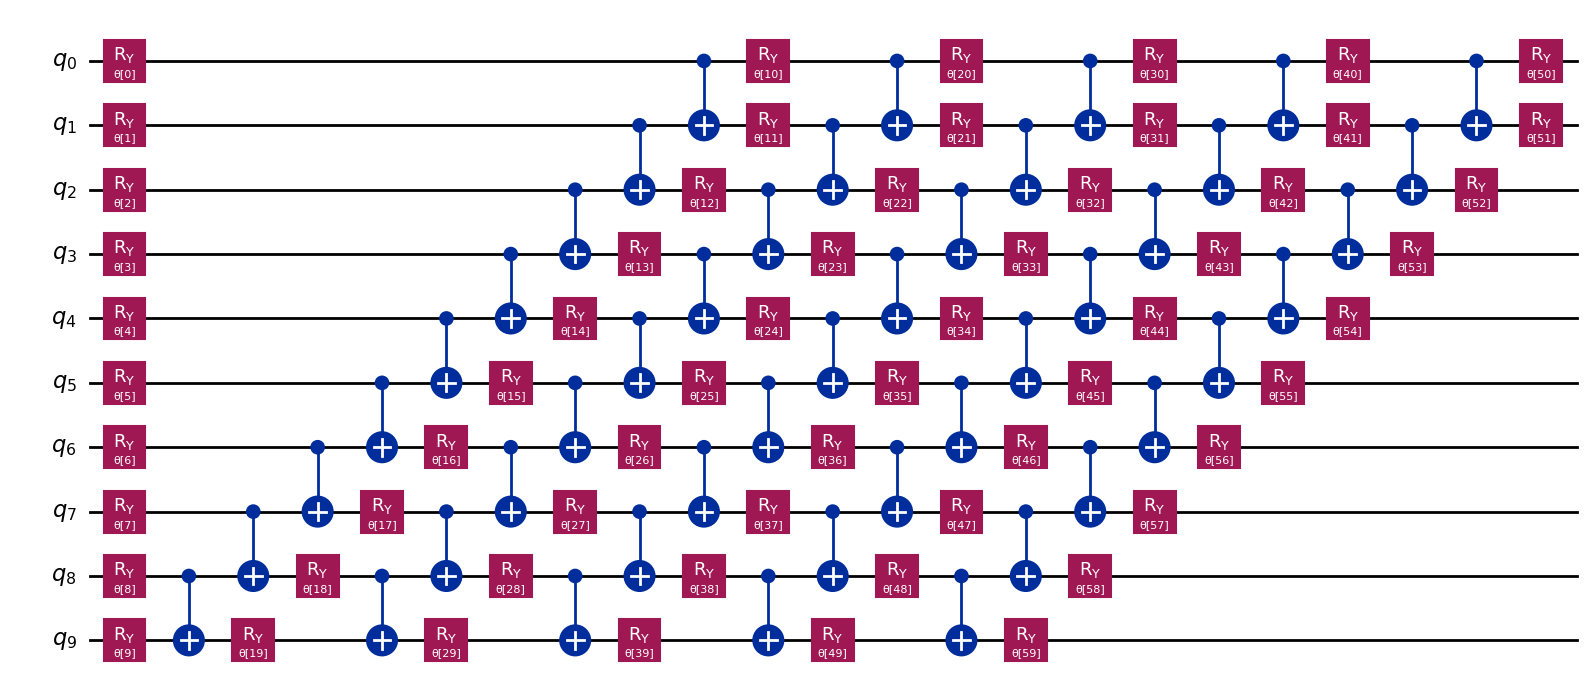

In [79]:
ansatz = RealAmplitudes(num_qubits, reps=ansatz_reps)
print(f"Anzahl trainierbarer Parameter: {ansatz.num_parameters}")
ansatz.decompose().draw("mpl", fold=-1)


Total Qubits:  17
Parameter:     60


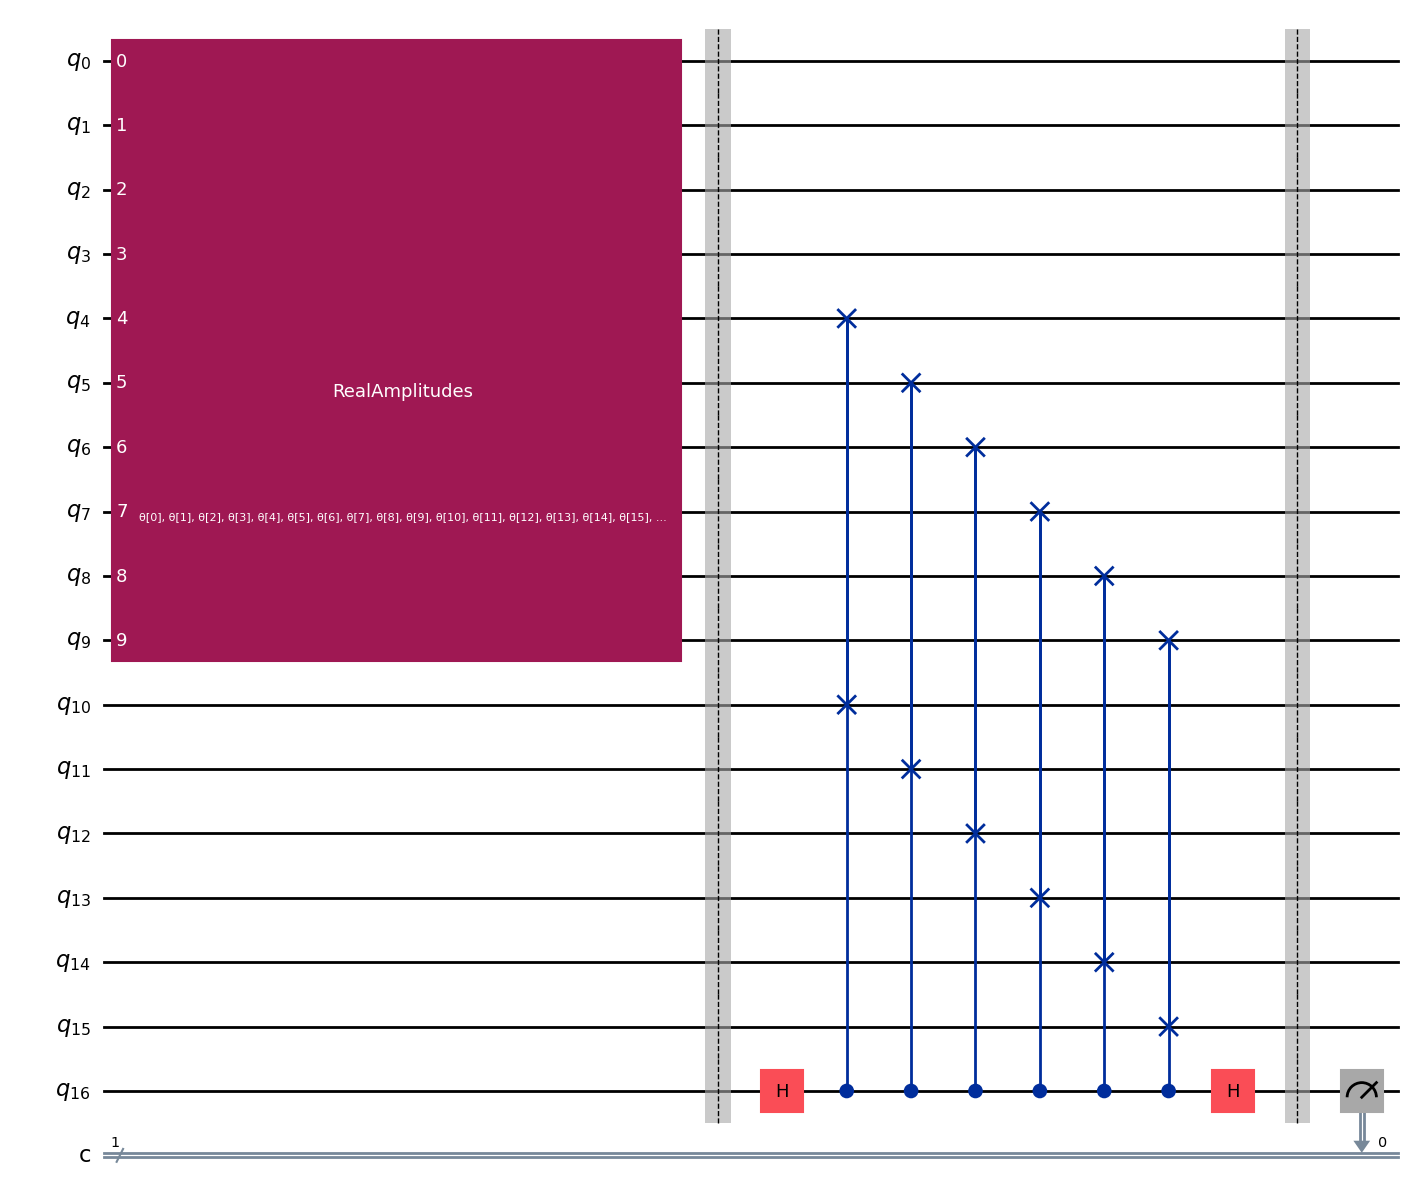

In [80]:
def auto_encoder_circuit(num_latent, num_trash, ansatz):
    """Encoder + SWAP-Test (Trash ↔ Referenzregister)."""
    from qiskit import QuantumRegister, ClassicalRegister
    total = num_latent + 2 * num_trash + 1
    aux   = num_latent + 2 * num_trash

    qr = QuantumRegister(total, "q")
    cr = ClassicalRegister(1, "c")
    qc = QuantumCircuit(qr, cr)

    qc.compose(ansatz, qubits=range(num_latent + num_trash), inplace=True)
    qc.barrier()

    qc.h(aux)
    for i in range(num_trash):
        qc.cswap(aux, num_latent + i, num_latent + num_trash + i)
    qc.h(aux)
    qc.barrier()

    qc.measure(aux, cr[0])
    return qc


ae_circuit = auto_encoder_circuit(num_latent, num_trash, ansatz)
print(f"Total Qubits:  {ae_circuit.num_qubits}")
print(f"Parameter:     {ae_circuit.num_parameters}")
ae_circuit.draw("mpl", fold=-1)


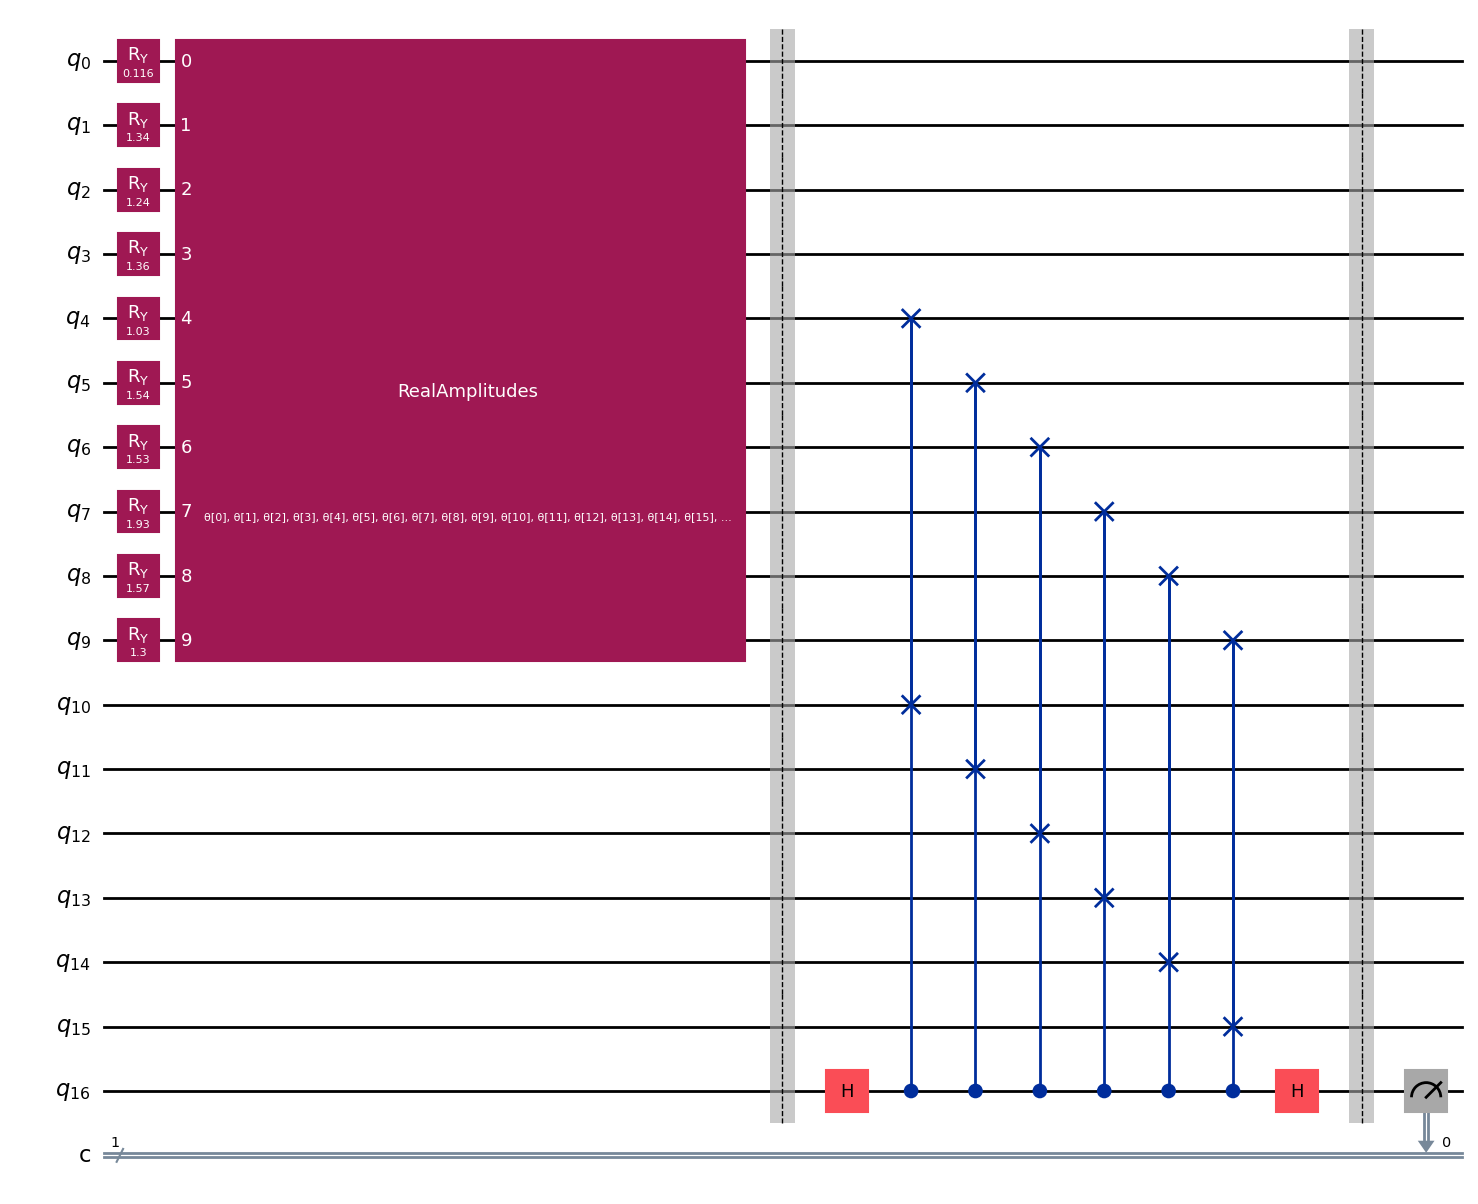

In [91]:
def build_full_circuit(state_prep, ae_circuit):
    """State-Prep + Autoencoder-Trainings-Schaltkreis."""
    full = QuantumCircuit(*ae_circuit.qregs, *ae_circuit.cregs)
    full.compose(state_prep, qubits=range(state_prep.num_qubits), inplace=True)
    full.compose(ae_circuit, inplace=True)
    return full


training_circuits = [build_full_circuit(sp, ae_circuit) for sp in training_states]

sampler = StatevectorSampler()
SHOTS = 1024

cost_history = []

def cost_function(params):
    """Mittel von P(|1⟩_aux) über alle Trainings-Flows."""
    param_dict = dict(zip(ansatz.parameters, params))
    bound = [qc.assign_parameters(param_dict) for qc in training_circuits]

    job    = sampler.run(bound, shots=SHOTS)
    result = job.result()

    cost = 0.0
    for pub_result in result:
        counts = pub_result.data.c.get_counts()
        total  = sum(counts.values())
        cost  += counts.get("1", 0) / total
    cost /= len(training_circuits)

    cost_history.append(cost)
    if len(cost_history) % 10 == 0:
        print(f"Iter {len(cost_history):4d}   cost = {cost:.4f}")
    return cost

## just clip to first 10 circuits for testing
training_circuits = training_circuits[:10]

training_circuits[0].draw("mpl")


In [97]:
import os

if os.path.exists("trained_params.npy"):
    initial_params = np.load("trained_params.npy")
    print("Gespeicherte Parameter geladen.")
else:
    initial_params = np.random.uniform(-0.1, 0.1, ansatz.num_parameters)
    print("Neue Zufallsparameter initialisiert.")
    
print(f"Starte Training mit {ansatz.num_parameters} Parametern, {len(training_circuits)} Trainings-Flows...")
print(f"Initiale Kosten: {cost_function(initial_params):.4f}\n")

result = minimize(
    cost_function,
    initial_params,
    method="COBYLA",
    options={"maxiter": 200, "rhobeg": 0.5, "disp": True},
)

optimal_params = result.x

np.save("trained_params.npy", optimal_params)
print("Parameter gespeichert.")

print(f"\nFinale Kosten:                {result.fun:.4f}")
print(f"Implizite mittlere Fidelität: {1 - 2*result.fun:.4f}")
print(f"Anzahl Funktionsauswertungen: {result.nfev}")


Gespeicherte Parameter geladen.
Starte Training mit 60 Parametern, 10 Trainings-Flows...
Initiale Kosten: 0.0936

Iter  410   cost = 0.1320
Iter  420   cost = 0.1344
Iter  430   cost = 0.1093
Iter  440   cost = 0.1164
Iter  450   cost = 0.1103
Iter  460   cost = 0.1091
Iter  470   cost = 0.0834
Iter  480   cost = 0.0785
Iter  490   cost = 0.0845
Iter  500   cost = 0.0839
Iter  510   cost = 0.0810
Iter  520   cost = 0.0757
Iter  530   cost = 0.0841
Iter  540   cost = 0.0846
Iter  550   cost = 0.0794
Iter  560   cost = 0.0792
Iter  570   cost = 0.0767
Iter  580   cost = 0.0790
Iter  590   cost = 0.0826
Iter  600   cost = 0.0754
Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 200   Least value of F = 0.0720703125
The corresponding X is:
[-0.18959738 -1.45791889 -0.55584648 -0.33547979  0.56568073 -0.72459013
 -0.34985672  0.17028224  0.21313472  0.29428719  0.03446034  0.0502418
 -0.28074283 -0.19885972  0.00909804 -0.06586829

In [98]:
np.save("trained_params.npy", optimal_params)
print("Parameter gespeichert.")

Parameter gespeichert.


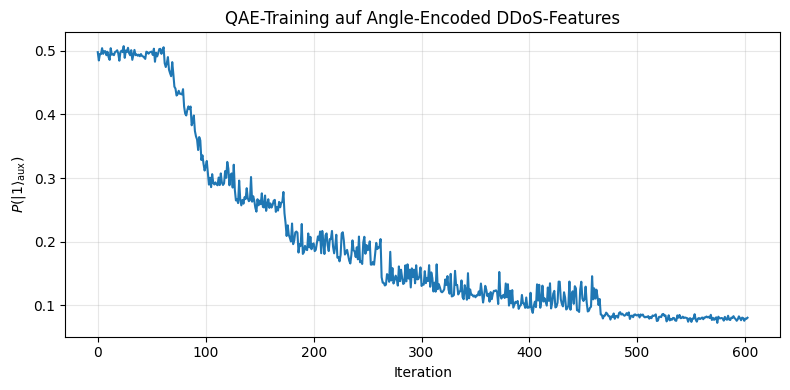

In [99]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel(r"$P(|1\rangle_{\mathrm{aux}})$")
plt.title("QAE-Training auf Angle-Encoded DDoS-Features")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [102]:
def reconstruct(state_prep, encoder_params):
    """Encode + Reset Trash + Decode → 10-Qubit-Schaltkreis (gemischter Zustand)."""
    encoder = ansatz.assign_parameters(
        dict(zip(ansatz.parameters, encoder_params))
    )
    decoder = encoder.inverse()

    qc = QuantumCircuit(num_qubits)
    qc.compose(state_prep, inplace=True)
    qc.compose(encoder, inplace=True)

    for i in range(num_latent, num_qubits):
        qc.reset(i)

    qc.compose(decoder, inplace=True)
    return qc

# also clip training states for testing
training_states = training_states[:10]


fidelities = []
for sp in training_states:
    qc      = reconstruct(sp, optimal_params)
    rho_out = DensityMatrix(qc)
    psi_in  = Statevector(sp)
    fidelities.append(state_fidelity(rho_out, psi_in))
    print(f"Fidelity: {fidelities[-1]:.4f}")

fidelities = np.array(fidelities)
print(f"Mittlere Fidelität: {fidelities.mean():.4f}")
print(f"Min:               {fidelities.min():.4f}")


Fidelity: 0.8197
Fidelity: 0.7857
Fidelity: 0.8273
Fidelity: 0.7960
Fidelity: 0.8300
Fidelity: 0.8256
Fidelity: 0.7996
Fidelity: 0.7953
Fidelity: 0.8109
Fidelity: 0.3432
Mittlere Fidelität: 0.7633
Min:               0.3432


In [124]:
_X = np.array([[0, 1], [1, 0]], dtype=complex)
_Z = np.array([[1, 0], [0, -1]], dtype=complex)

FEATURE_NAMES = [
    "Flow Duration (us)",
    "Total Fwd Packets",
    "Total Bwd Packets",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean (us)",
    "SYN Flag Count",
    "Packet Length Variance",
]

def angle_decode_density(rho, num_qubits, rotation="ry"):
    """Winkel-Decoding aus reduzierten 1-Qubit-Dichtematrizen."""
    angles = np.zeros(num_qubits)
    for i in range(num_qubits):
        rho_i = partial_trace(rho, [j for j in range(num_qubits) if j != i]).data
        ex = float(np.real(np.trace(rho_i @ _X)))
        ez = float(np.real(np.trace(rho_i @ _Z)))
        if rotation == "ry":
            angles[i] = np.arctan2(ex, ez)
        else:
            raise NotImplementedError("nur ry hier — siehe angle_encoding_ddos.ipynb")
    return angles

## also cut angles for testing
angles = training_angles[:10]

example_state = training_states[0]

qc_recon = reconstruct(example_state, optimal_params)
rho_out  = DensityMatrix(qc_recon)

angles_in    = training_angles[:]
angles_recon = angle_decode_density(rho_out, num_qubits, rotation="ry")

raw_in    = df_final.iloc[:].values
raw_recon = denormalize_features(angles_recon)

# compare original vs decoded features for the first 5 flow

#print(f"raw_in    = {raw_in[0]}")
#print(f"raw_recon = {raw_recon[:10]}")
#print(f"angles_in    = {angles_in[:10]}")
#print(f"angles_recon = {angles_recon[:10]}")

print(f"Differenz raw_in vs raw_recon: {raw_in - raw_recon}")
print(f"Differenz angles_in vs angles_recon: {angles_in - angles_recon}")


Differenz raw_in vs raw_recon: [[-0.12989097 -0.53698754 -0.31093085 ... -0.15859319  0.24583683
  -0.01685916]
 [-0.23479276 -0.30016053 -0.25523952 ... -0.02283741  0.32733316
  -0.22429232]
 [-0.18378954 -0.44765604 -0.35666752 ... -0.17138518  0.23928248
  -0.07450221]
 ...
 [ 6.46204848  2.69972181  1.93948316 ... -0.04691214  0.39968843
   0.42794569]
 [ 5.67447991 -2.41873217 -1.84665323 ... -0.62963761 -0.19901381
  -0.50567417]
 [ 7.95916123  5.52207708 -1.86282445 ... -0.18159712 -0.18521665
   0.04609628]]
Differenz angles_in vs angles_recon: [[-0.03365068 -0.12957531 -0.09358866 ... -0.11248863  0.14485834
  -0.01448737]
 [-0.06082745 -0.07242886 -0.07682584 ... -0.01619836  0.19287972
  -0.19273827]
 [-0.04761411 -0.10801958 -0.10735517 ... -0.12156187  0.14099622
  -0.06402104]
 ...
 [ 1.67411436  0.65144397  0.58377491 ... -0.03327433  0.23551477
   0.36774113]
 [ 1.47008001 -0.58364106 -0.55583356 ... -0.44659593 -0.11726807
  -0.43453456]
 [ 2.06196938  1.33247945 -0.5

In [125]:
# Decode the 10 sub features back again to original feature space

# 1. PCA inverse: 10D → 32D (Latent Space)
latent_32d = pca_on_latent.inverse_transform(final_representation)  # shape: (N, 32)

# 2. Autoencoder Decoder: 32D → 27D (skalierter Raum [0,1])
latent_tensor = torch.tensor(latent_32d, dtype=torch.float32)
with torch.no_grad():
    reconstructed_scaled = autoencoder.decoder(latent_tensor).numpy()  # shape: (N, 27)

# 3. MinMaxScaler inverse: [0,1] → Original Feature Range
X_reconstructed = scaler_01.inverse_transform(reconstructed_scaled)  # shape: (N, 27)

# Als DataFrame
df_reconstructed = pd.DataFrame(X_reconstructed, columns=X.columns)

    

In [126]:
# Originaldaten skaliert
X_original_scaled = scaler_01.transform(X.values)  # shape: (N, 27)

# Rekonstruktion (aus dem Code oben)
latent_32d = pca_on_latent.inverse_transform(final_representation)
latent_tensor = torch.tensor(latent_32d, dtype=torch.float32)
with torch.no_grad():
    X_reconstructed_scaled = autoencoder.decoder(latent_tensor).numpy()

# Differenz pro Sample und Feature
diff = X_reconstructed_scaled - X_original_scaled  # shape: (N, 27)

# Metriken
mse_per_sample = np.mean(diff**2, axis=1)        # MSE pro Sample (N,)
mse_per_feature = np.mean(diff**2, axis=0)       # MSE pro Feature (27,)
mae_per_sample  = np.mean(np.abs(diff), axis=1)  # MAE pro Sample
overall_mse     = np.mean(diff**2)

print(f"Gesamt MSE:  {overall_mse:.6f}")
print(f"Gesamt MAE:  {np.mean(np.abs(diff)):.6f}")

Gesamt MSE:  0.000386
Gesamt MAE:  0.009367


/opt/miniconda3/envs/fp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [127]:
X_reconstructed_orig = scaler_01.inverse_transform(X_reconstructed_scaled)
X_original_orig = X.values

diff_orig = X_reconstructed_orig - X_original_orig

# Welche Features haben den größten Fehler?
mse_per_feature_orig = np.mean(diff_orig**2, axis=0)
feature_errors = pd.Series(mse_per_feature_orig, index=X.columns).sort_values(ascending=False)
print(feature_errors)

total_bytes_sum            1.100589e+13
bps_max                    2.459199e+10
bps_mean                   1.570907e+09
total_packets_sum          2.807143e+07
pps_max                    4.247903e+05
pps_mean                   7.349996e+03
unique_dst_port            3.014892e+02
packet_size_avg_mean       2.213323e+02
packet_size_avg_std        2.115833e+02
inter_arrival_std_mean     4.586937e+01
inter_arrival_mean_mean    1.815009e+01
duration_max               1.324336e+01
duration_mean              6.786355e-01
unique_dst_ip              6.624015e-02
dst_port_concentration     9.508744e-04
dst_concentration          8.769483e-04
low_outbound_share         4.629806e-04
outbound_ratio_mean        3.885387e-04
small_packet_share         3.320729e-04
unique_protocols           2.589542e-04
tcp_share                  1.087554e-04
udp_share                  1.003539e-04
outbound_ratio_min         7.883505e-05
high_pps_share             3.767631e-05
icmp_share                 1.305763e-05


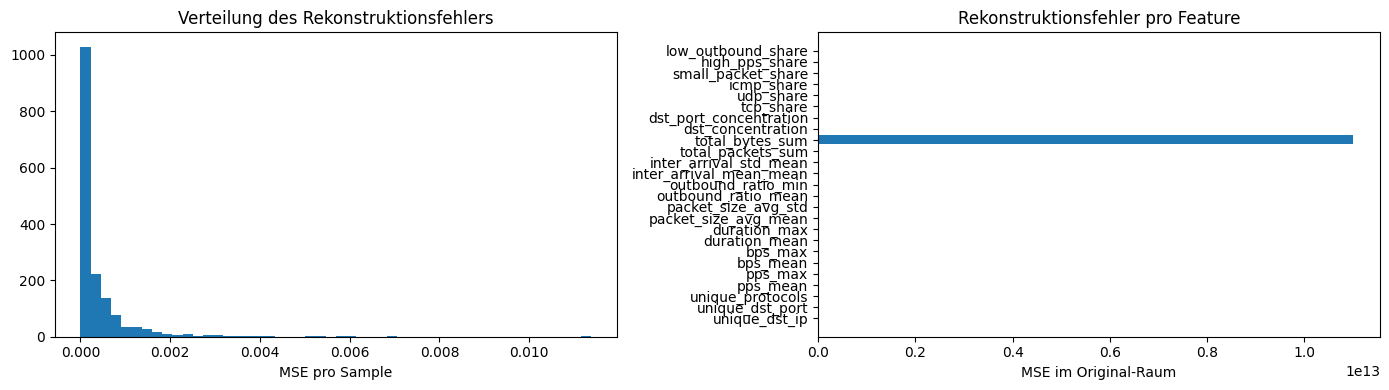

In [128]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# MSE pro Sample — Ausreißer sichtbar machen
axes[0].hist(mse_per_sample, bins=50)
axes[0].set_xlabel("MSE pro Sample")
axes[0].set_title("Verteilung des Rekonstruktionsfehlers")

# Fehler pro Feature
axes[1].barh(X.columns, mse_per_feature_orig)
axes[1].set_xlabel("MSE im Original-Raum")
axes[1].set_title("Rekonstruktionsfehler pro Feature")

plt.tight_layout()
plt.show()
